# EDA Codealong

## Data ingestion and Preliminary DA

In [101]:
# importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import scipy as stat
from zipfile import ZipFile


In [102]:
# let load the data from the zipfile
path=r"C:\Users\OLASQUARE\Downloads\Compressed\wine+quality.zip"

with ZipFile(path, 'r') as zip_ref:
    zip_ref.printdir()

File Name                                             Modified             Size
winequality-red.csv                            2023-05-22 22:24:00        84199
winequality-white.csv                          2023-05-22 22:24:00       264426
winequality.names                              2023-05-22 22:24:00         3305


In [103]:
# loading only winequality-white.csv
with ZipFile(path) as zip_ref:
    with zip_ref.open("winequality-white.csv") as f:
        white_wine= pd.read_csv(f, sep=";")

In [104]:
# snap shot of the data
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [105]:
white_wine.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [106]:
# let pick numeric colums
numeric_cols= white_wine.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [107]:
white_wine[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [108]:
# let check the column dtype
white_wine.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [109]:
white_wine.quality.unique()

array([6, 5, 7, 8, 4, 3, 9], dtype=int64)

| Numeric | Category   | Meaning               |
| ------- | ---------- | --------------------- |
| 3–4     | **Low**    | Poor quality wines    |
| 5–6     | **Medium** | Average/typical wines |
| 7–8+    | **High**   | Premium-quality wines |


In [110]:
# let define a function to map the quality to categories

def map_quality_category(quality):
    if quality<=4:
        return "Low"
    elif quality<=6:
        return "Medium"
    else:
        return "High"
    
# make use of the function
white_wine['quality_value']= white_wine['quality'].apply(map_quality_category)
white_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_value
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,Medium
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,Medium
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,Medium
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Medium


In [111]:
# make a copy of the data
df=white_wine.copy()

# EDA started here

## 1. Univariate analysis
Analysing one column/features at a time

What to look out for when carrying out univariate analysis:

1. Distribution -Normal, poisson, binomial, Bernoulli distributions
2. How they are organized around the centre - measure of central tendency(mean, median and mode)
3. How they are dispersed from the centre - measure of dispersion(standard deviation, variance, kurtosis, skewness)
4. The type of plots that can be used include  **histogram**,**boxplots**, **countplot**.

The idea behind univariate analysis is To understand each variable individually, its distribution, central tendency, spread, shape, and presence of outliers..

### Univariate analysis for Numerical features

In [112]:
# let define a function to carry out univariate analysis 
# Displays summary statistics, skewness, kurtosis, histogram, KDE, and boxplot.

def univariate_analysis(df, column):
    print("--"*36)
    print (f"Feature: {column}")
    print("--"*36)
    print(df[column].describe().to_frame().T)
    print(f"\nSkewness: {df[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    # let plot the graphs
    plt.figure(figsize=(12, 4))
    # hsitorgram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True, bins=35,color="teal")
    plt.title(f"\n Distribution of {column}", fontsize=13,fontweight="bold")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    # boxplot
    plt.subplot(1,2,2)
    sns.boxplot(df[column], color="teal")
    plt.title(f"\nBoxplot of {column}",fontsize=13, fontweight="bold")

    plt.tight_layout
    plt.show()

    # tell if data is skew and what level
    if abs(df[column].skew())>1:
        print(f"\n {column} is highly skewed. Consider log or Box-Cox transformation.")
    elif abs(df[column].skew())>0.5:
        print(f"{column} is moderately skewed.")
    else:
        print(f"{column} is fairly symmetric.")
    print()



------------------------------------------------------------------------
Feature: fixed acidity
------------------------------------------------------------------------
                count      mean       std  min  25%  50%  75%   max
fixed acidity  4898.0  6.854788  0.843868  3.8  6.3  6.8  7.3  14.2

Skewness: 0.648
Kurtosis: 2.172


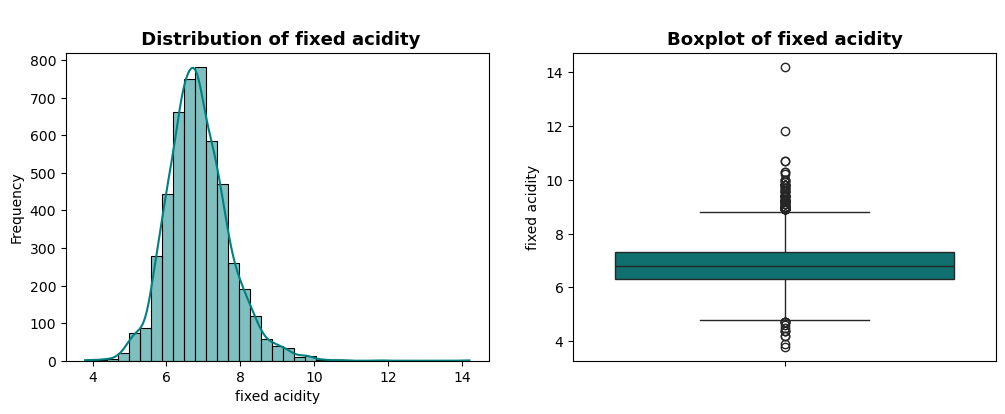

fixed acidity is moderately skewed.

------------------------------------------------------------------------
Feature: volatile acidity
------------------------------------------------------------------------
                   count      mean       std   min   25%   50%   75%  max
volatile acidity  4898.0  0.278241  0.100795  0.08  0.21  0.26  0.32  1.1

Skewness: 1.577
Kurtosis: 5.092


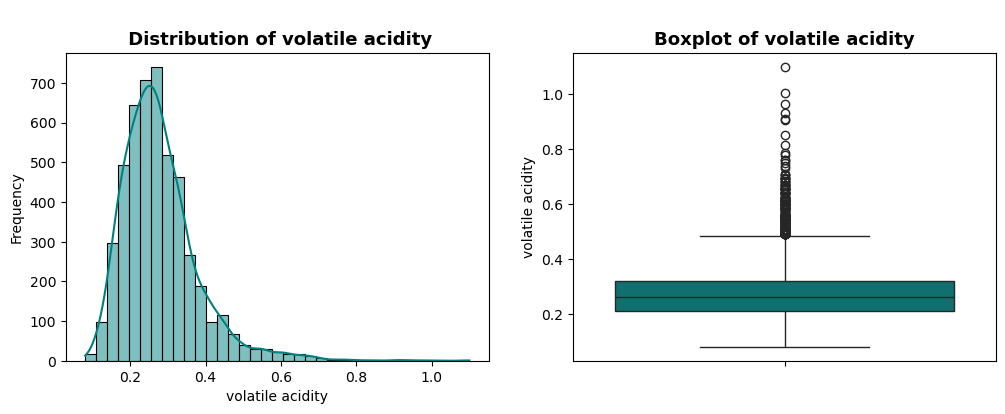


 volatile acidity is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: citric acid
------------------------------------------------------------------------
              count      mean      std  min   25%   50%   75%   max
citric acid  4898.0  0.334192  0.12102  0.0  0.27  0.32  0.39  1.66

Skewness: 1.282
Kurtosis: 6.175


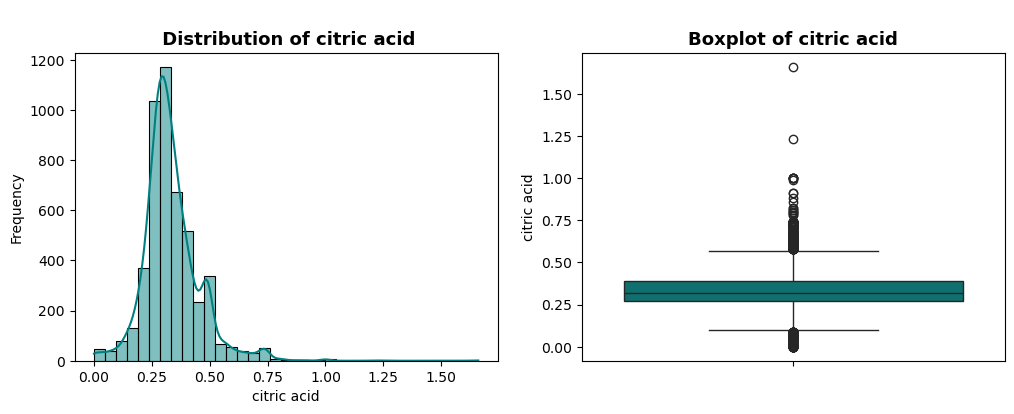


 citric acid is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: residual sugar
------------------------------------------------------------------------
                 count      mean       std  min  25%  50%  75%   max
residual sugar  4898.0  6.391415  5.072058  0.6  1.7  5.2  9.9  65.8

Skewness: 1.077
Kurtosis: 3.470


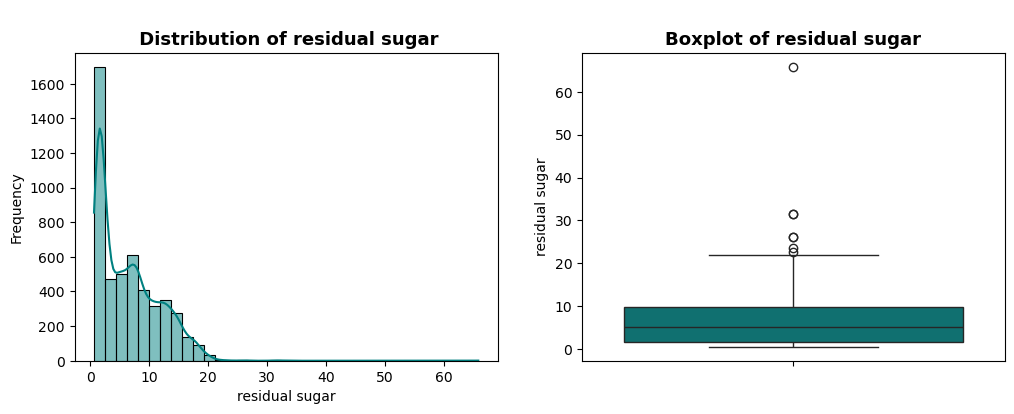


 residual sugar is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: chlorides
------------------------------------------------------------------------
            count      mean       std    min    25%    50%   75%    max
chlorides  4898.0  0.045772  0.021848  0.009  0.036  0.043  0.05  0.346

Skewness: 5.023
Kurtosis: 37.565


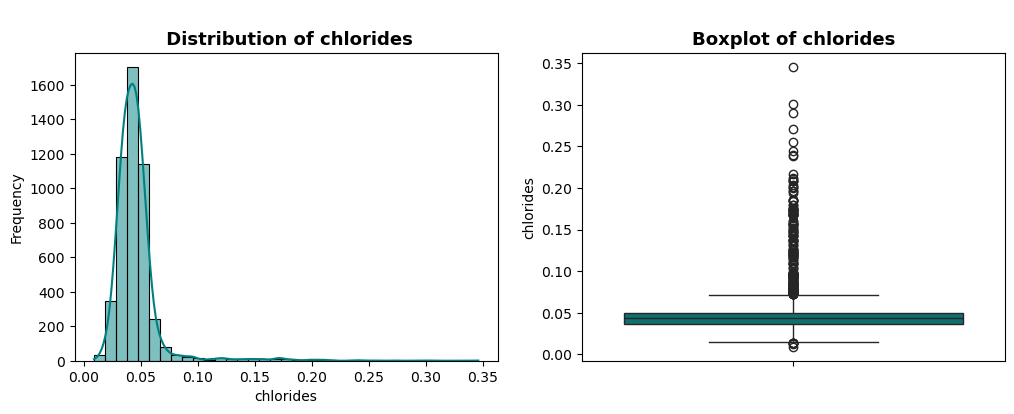


 chlorides is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: free sulfur dioxide
------------------------------------------------------------------------
                      count       mean        std  min   25%   50%   75%  \
free sulfur dioxide  4898.0  35.308085  17.007137  2.0  23.0  34.0  46.0   

                       max  
free sulfur dioxide  289.0  

Skewness: 1.407
Kurtosis: 11.466


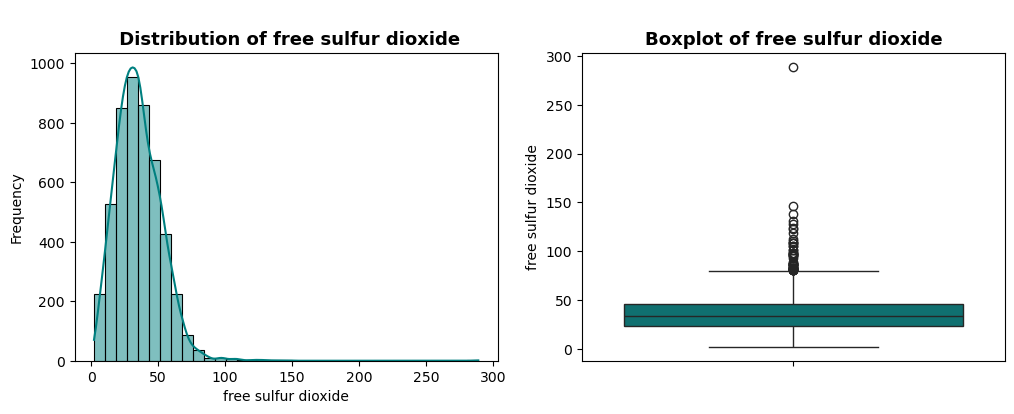


 free sulfur dioxide is highly skewed. Consider log or Box-Cox transformation.

------------------------------------------------------------------------
Feature: total sulfur dioxide
------------------------------------------------------------------------
                       count        mean        std  min    25%    50%    75%  \
total sulfur dioxide  4898.0  138.360657  42.498065  9.0  108.0  134.0  167.0   

                        max  
total sulfur dioxide  440.0  

Skewness: 0.391
Kurtosis: 0.572


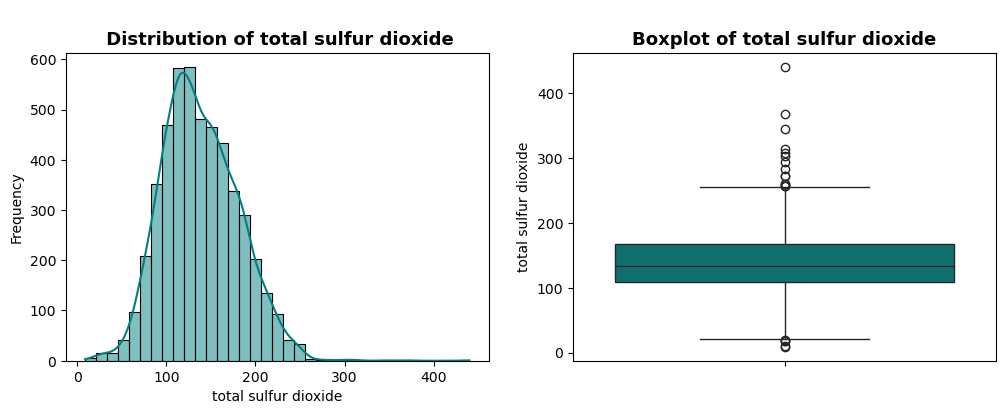

total sulfur dioxide is fairly symmetric.

------------------------------------------------------------------------
Feature: density
------------------------------------------------------------------------
          count      mean       std      min       25%      50%     75%  \
density  4898.0  0.994027  0.002991  0.98711  0.991723  0.99374  0.9961   

             max  
density  1.03898  

Skewness: 0.978
Kurtosis: 9.794


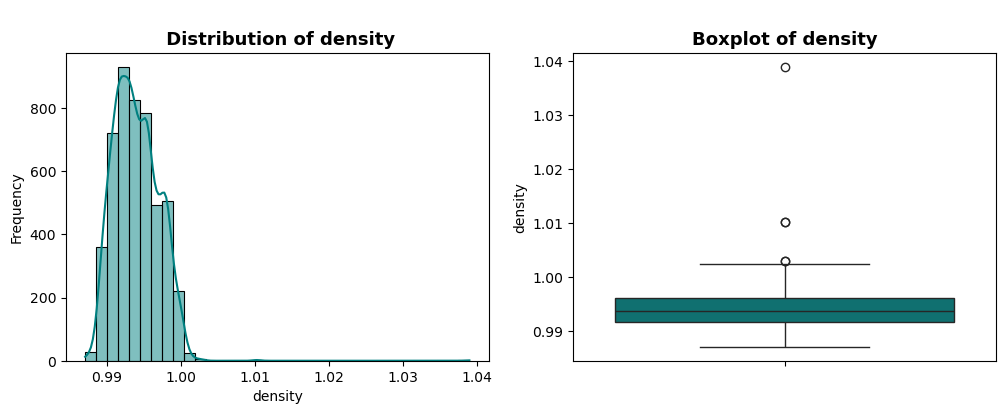

density is moderately skewed.

------------------------------------------------------------------------
Feature: pH
------------------------------------------------------------------------
     count      mean       std   min   25%   50%   75%   max
pH  4898.0  3.188267  0.151001  2.72  3.09  3.18  3.28  3.82

Skewness: 0.458
Kurtosis: 0.531


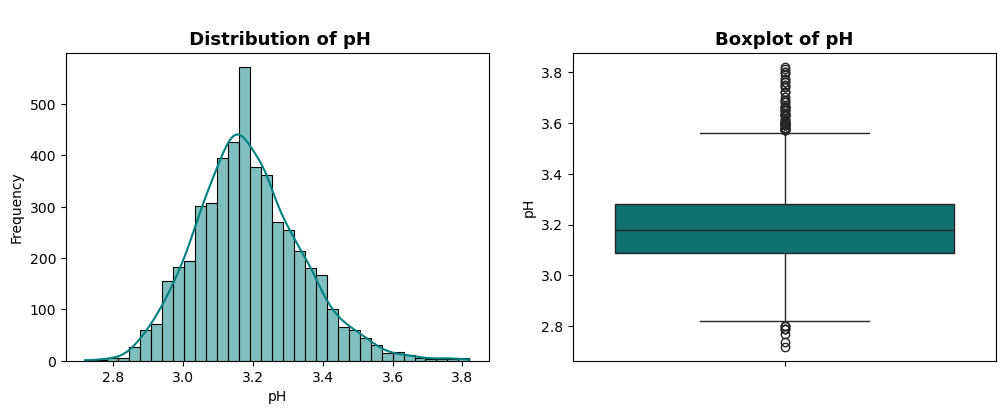

pH is fairly symmetric.

------------------------------------------------------------------------
Feature: sulphates
------------------------------------------------------------------------
            count      mean       std   min   25%   50%   75%   max
sulphates  4898.0  0.489847  0.114126  0.22  0.41  0.47  0.55  1.08

Skewness: 0.977
Kurtosis: 1.591


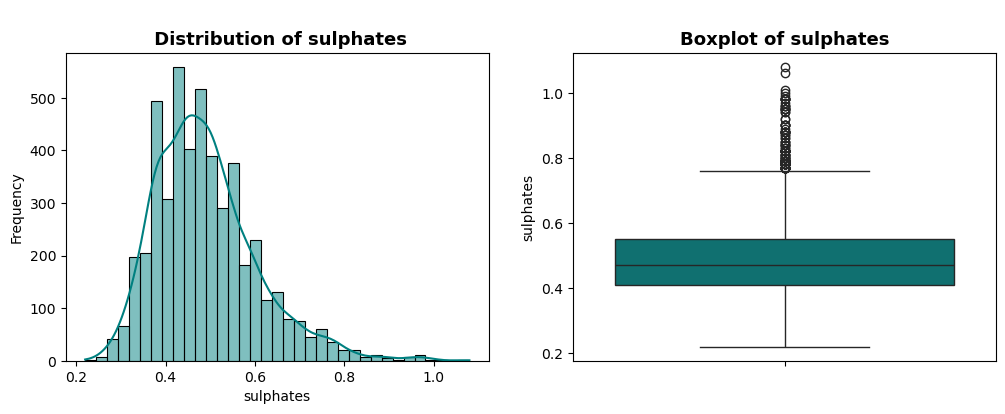

sulphates is moderately skewed.

------------------------------------------------------------------------
Feature: alcohol
------------------------------------------------------------------------
          count       mean       std  min  25%   50%   75%   max
alcohol  4898.0  10.514267  1.230621  8.0  9.5  10.4  11.4  14.2

Skewness: 0.487
Kurtosis: -0.698


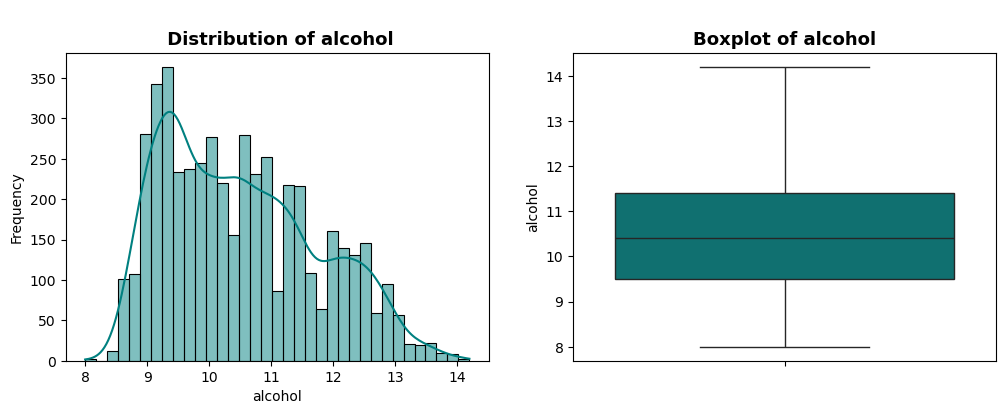

alcohol is fairly symmetric.

------------------------------------------------------------------------
Feature: quality
------------------------------------------------------------------------
          count      mean       std  min  25%  50%  75%  max
quality  4898.0  5.877909  0.885639  3.0  5.0  6.0  6.0  9.0

Skewness: 0.156
Kurtosis: 0.217


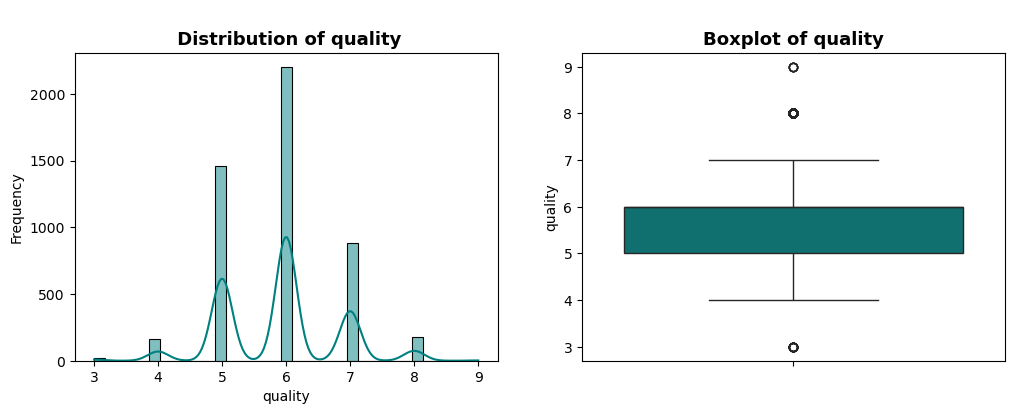

quality is fairly symmetric.



In [113]:
# let loop 2ru our fuction with each feature

for column in numeric_cols:
    univariate_analysis(df,column)
    

### Univariate analysis for categorical feature/coulmn


In [141]:
# let define fuction for univariate on categorical feature
# Displays frequency table, proportion, and a countplot.

def univariate_analysis_cat(df, column):
    print("--"*36)
    print (f"Feature: {column}")
    print("--"*36)

    # frequncy table
    freq= df[column].value_counts()
    prop= df[column].value_counts(normalize=True) * 100
    summary= pd.DataFrame({"Count":freq, "Percentage":prop.round(2)})
    print(summary)
    print()

    # counter plot
    plt.figure(figsize=(8,6))
    ax=sns.countplot(x=column,data=df, hue=column, order=freq.index)
    plt.title(f'\nDistribution of {column}', fontsize=13, fontweight="bold")
    plt.xlabel(column)
    plt.ylabel("Count")

    # display percentage on each bar
    tot= len(df[column])
    for b in ax.patches:
        height= b.get_height()
        ax.text(b.get_x()+ b.get_width()/2, height+1,
                f'{(height/tot)*100:.1f}%',ha='center')

    plt.tight_layout()
    plt.show()

    

In [142]:
# let get the categorical feature
categorical_cols= df.select_dtypes(["object"]).columns
categorical_cols

Index(['quality_value'], dtype='object')

------------------------------------------------------------------------
Feature: quality_value
------------------------------------------------------------------------
               Count  Percentage
quality_value                   
Medium          3655       74.62
High            1060       21.64
Low              183        3.74



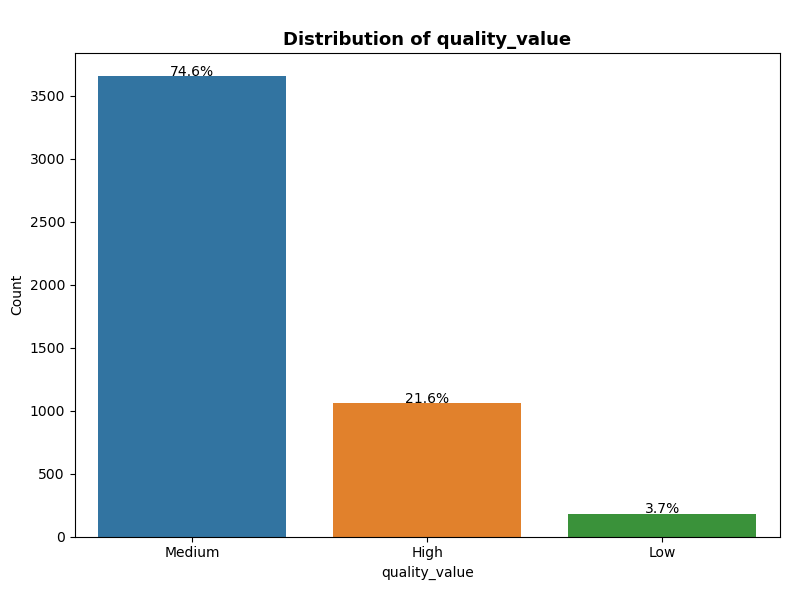

In [143]:
# let use the function
univariate_analysis_cat(df,"quality_value")

### Key Univariate Findings

| Feature Type          |Observation                                  | What It Means / Implication          |
| ----------------------| ------------------------------------------- | ------------------------------------ |